In [3]:
import polars as pl

df = pl.read_parquet("datasets/dataset_merged.parquet")

df_full=df

In [6]:
import polars as pl

df = pl.read_csv("datasets/dataset_homology_split_test.csv")
df2 = pl.read_csv("datasets/dataset_homology_split_train.csv")
df3 = pl.read_csv("datasets/dataset_homology_split_validation.csv")

df_full = pl.concat([df, df2, df3])

df_full

wt_sequence,mut_sequence,mutation,fitness,cath_class,cath_arch,cath_topology,cath_homology,data_source,reverse
str,str,str,f64,str,i64,i64,i64,str,bool
"""MTTKRSLFVRLVPCRCLRGEEETVTTLDYS…","""MTTKRSLFVRLVPCRCLRGEEETVTTLDYS…","""C1372G""",-0.286319,"""G3DSA:3""",30,730,30,"""lehner""",false
"""MVQQTNNAENTEALLAGESSDSGAGLELGI…","""MVQQTNNAENTEALLAGESSDSGAGLELGI…","""V124P""",-0.042066,"""G3DSA:3""",30,1370,10,"""lehner""",false
"""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""GQTVVIGDTTYHLNNPEAAQQIAKELAKKY…","""V35K""",-0.094397,"""G3DSA:1""",10,260,40,"""megascale""",false
"""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""SAGGSAGGSAGGSAGGMISNAKIARINELA…","""K32W:E42W""",0.233383,"""G3DSA:1""",20,58,90,"""megascale""",true
"""MGKITFYEDRAFQGRSYETTTDCPNLQPYF…","""MGKITFYEDRAFQGRSYETTTDCPNLQPYF…","""Y68Q""",0.012739,"""G3DSA:1""",10,10,10,"""lehner""",false
…,…,…,…,…,…,…,…,…,…
"""SAGGTYTWNTKEEAKQAFKELLKEKRVPSN…","""SAGGTYTWNTKEEAKQAFKELLKEKRVPSN…","""L49S""",-0.258713,"""G3DSA:1""",20,58,60,"""megascale""",false
"""MGKKSRAVPGRRPILQLSPPGPRGSTPGRD…","""MGKKSRAVPGRRPILQLSPPGPRGSTPGRD…","""*209S""",-0.345165,"""G3DSA:3""",10,20,510,"""lehner""",false
"""SAGGSHSHMSHTQVIELERKFSHQKYLSAP…","""SAGGSHSHMSHTQVIELERKFSHQKYLSAP…","""N52P""",-0.168865,"""G3DSA:3""",40,50,10810,"""megascale""",false


In [9]:
df_full.filter(pl.col("reverse") == False).select(pl.col("wt_sequence").str.len_chars()).describe()

statistic,wt_sequence
str,f64
"""count""",864033.0
"""null_count""",0.0
"""mean""",547.629004
"""std""",768.21374
"""min""",44.0
"""25%""",72.0
"""50%""",252.0
"""75%""",744.0
"""max""",8525.0


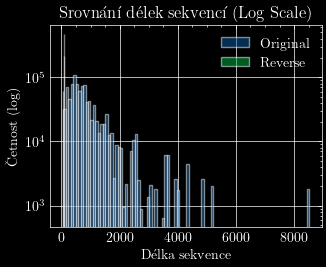

In [8]:
df_full.filter(pl.col("reverse") == False).select(pl.col("fitness")).describe()

statistic,fitness
str,f64
"""count""",864033.0
"""null_count""",0.0
"""mean""",-0.140211
"""std""",0.176915
"""min""",-0.980373
"""25%""",-0.246205
"""50%""",-0.097387
"""75%""",-0.018705
"""max""",0.986593


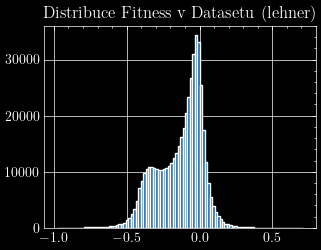

In [13]:

import matplotlib.pyplot as plt
plt.hist(df_full.filter(pl.col("reverse") == False).filter(pl.col("data_source") == "lehner").select(pl.col("fitness")).to_series(), bins=100)
plt.title("Distribuce Fitness v Datasetu (lehner)")
plt.show()

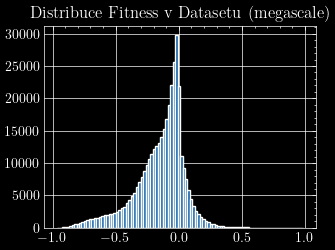

In [14]:
plt.hist(df_full.filter(pl.col("reverse") == False).filter(pl.col("data_source") == "megascale").select(pl.col("fitness")).to_series(), bins=100)
plt.title("Distribuce Fitness v Datasetu (megascale)")
plt.show()